In [32]:
import torch
import torchvision

print(torch.__version__)
print(torchvision.__version__)

2.10.0+cpu
0.25.0+cpu


In [33]:
from torchvision import datasets, transforms

train_dataset = datasets.MNIST(
    root='./data',
    train=True,
    download=True,
    transform=transforms.ToTensor())

####  **TO cheak data is loaded**

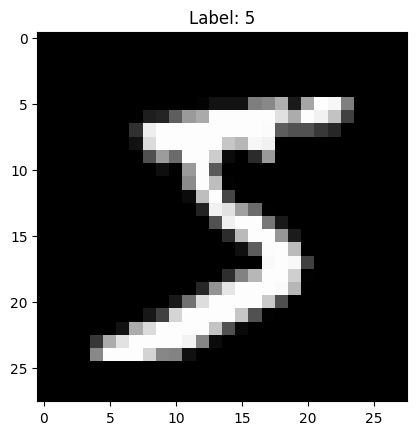

In [34]:
import matplotlib.pyplot as plt

image, label = train_dataset[0]

plt.imshow(image.squeeze(), cmap="gray")
plt.title(f"Label: {label}")
plt.show()

In [35]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np 


### **Preprocessing**

In [36]:
transform = transforms.Compose([
    transforms.ToTensor(),                  # 0-255 → 0-1
    transforms.Normalize((0.5,), (0.5,))   # center around 0, std≈1
])

In [37]:
# data spliting
train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset  = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

# DataLoader
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True) 
test_loader = DataLoader(test_dataset, batch_size=1000, shuffle=False)

### **Model Architecture**

In [38]:
import torch.nn as nn

class FeedForwardNeuralNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        # Define the layers of the network
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(28*28, 128)
        self.relu1 = nn.ReLU()
        self.fc2 = nn.Linear(128, 64)
        self.relu2 = nn.ReLU()
        self.output = nn.Linear(64, 10)

    def forward(self, x):
        x = self.flatten(x)
        x = self.fc1(x)
        x = self.relu1(x)
        x = self.fc2(x)
        x = self.relu2(x)
        x = self.output(x)
        return x

# Create a instance of the model
model = FeedForwardNeuralNetwork()

In [39]:
#  Loss  & Optimizer 
Loss= nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [40]:
#  Training 
epochs = 5
train_losses, train_accuracies = [], []

for epoch in range(epochs):
    model.train()
    correct, total, running_loss = 0, 0, 0.0
    
    for data, target in train_loader:
        optimizer.zero_grad()
        output = model(data)
        loss = Loss(output, target)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        _, predicted = torch.max(output.data, 1)
        total += target.size(0)
        correct += (predicted == target).sum().item()
    
    epoch_loss = running_loss / len(train_loader)
    epoch_acc = 100 * correct / total
    train_losses.append(epoch_loss)
    train_accuracies.append(epoch_acc)
    
    print(f"Epoch {epoch+1}/{epochs}, Loss: {epoch_loss:.4f}, Accuracy: {epoch_acc:.2f}%")




Epoch 1/5, Loss: 0.3912, Accuracy: 88.24%
Epoch 2/5, Loss: 0.1868, Accuracy: 94.31%
Epoch 3/5, Loss: 0.1367, Accuracy: 95.81%
Epoch 4/5, Loss: 0.1114, Accuracy: 96.61%
Epoch 5/5, Loss: 0.0958, Accuracy: 97.02%


### **Model Evaluation**

In [52]:
test_accuracies = []

for epoch in range(epochs):
    # Training code here ...

    # Compute Validation Accuracy per epoch
    model.eval()
    correct_test = 0
    total_test = 0
    with torch.no_grad():
        for images, labels in test_loader:
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            total_test += labels.size(0)
            correct_test += (predicted == labels).sum().item()
    # Average accuracy for the whole test set
    test_acc = 100 * correct_test / total_test
    test_accuracies.append(test_acc)

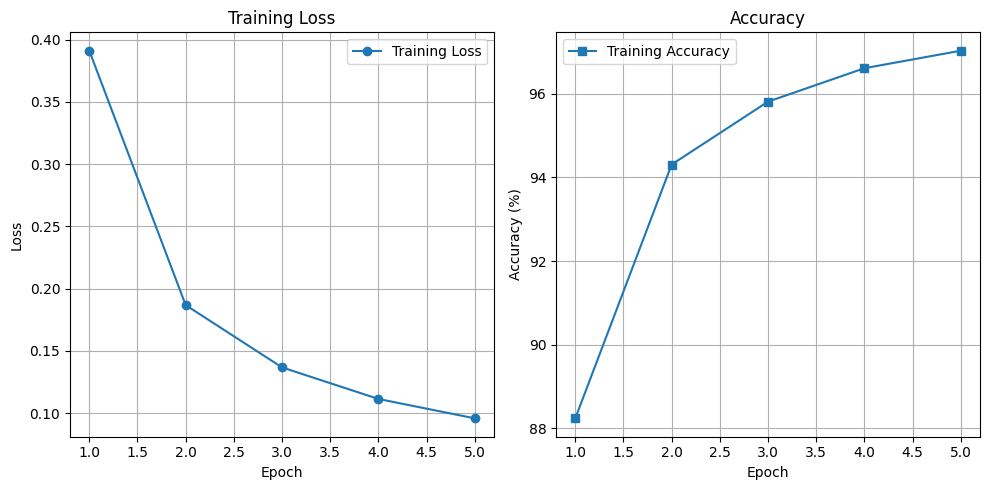

In [57]:
epochs_range = range(1, epochs+1)

plt.figure(figsize=(10,5))

# Training Loss
plt.subplot(1,2,1)
plt.plot(epochs_range, train_losses, 'o-', label='Training Loss')
plt.title('Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)
plt.legend()

# Training  Accuracy
plt.subplot(1,2,2)
plt.plot(epochs_range, train_accuracies, 's-', label='Training Accuracy')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

In [56]:
model.eval() 
correct, total = 0, 0 
with torch.no_grad(): 
    for data, target in test_loader: 
        output = model(data) 
        _, predicted = torch.max(output.data, 1) 
        total += target.size(0) 
        correct += (predicted == target).sum().item() 
print(f"Test Accuracy: {100 * correct / total:.2f}%")

Test Accuracy: 97.06%
